# Trabalho de IA: Busca Heurística e Árvores de Decisão

**Disciplina:** Inteligência Computacional (CESUPA), Profa. Polyana Santos Fonseca Nascimento

**Equipe:** Ana Alice, Caio e Yasmin

**Modalidades:** I. Busca heurística (Parte I) e IV. Árvore de decisão (Parte II)

### Declaração de uso de IA generativa
* **Ferramenta:** Claude (Anthropic), via Claude Code.
* **Finalidade:** apoio na estruturação das funções de medição e dos gráficos, correção de erros no código da Parte I (peso das arestas, heurística e critério de parada do A\* Bidirecional) e revisão dos textos explicativos.
* **Extensão:** parcial. A escolha dos problemas, dos dados e dos algoritmos foi da equipe; a IA sugeriu trechos de código e de texto.
* **Validação:** o custo encontrado pelo A\* foi conferido com o algoritmo de Dijkstra do NetworkX, o notebook foi executado do zero e todo o conteúdo foi revisado pela equipe.

### Como reproduzir
1. Python 3.12. Criar o ambiente e instalar as dependências:
   ```
   python -m venv venv
   source venv/bin/activate      # Windows: venv\Scripts\activate
   pip install -r requirements.txt
   ```
2. É preciso internet: o mapa (OpenStreetMap) e os dados dos vinhos (OpenML) são baixados na primeira execução.
3. Executar todas as células em ordem (*Restart Kernel* → *Run All*).

# Parte I: Busca heurística — rota mais curta em San Francisco

### Problema
Encontrar a **rota de carro mais curta (em metros)** entre dois pontos de San Francisco (EUA), como faz um GPS. O mapa real vem do OpenStreetMap, baixado com a biblioteca **OSMnx**.

### Representação
A cidade vira um **grafo direcionado**: cada cruzamento é um **nó**, cada trecho de rua é uma **aresta** e o **custo** da aresta é o comprimento da rua em metros. É direcionado porque existem ruas de mão única.

| Elemento | No problema |
| --- | --- |
| Estado | Estar em um cruzamento (nó) |
| Ação | Seguir por uma rua até o próximo cruzamento |
| Custo | Comprimento da rua (metros) |
| Objetivo | Chegar ao cruzamento de destino |

### Por que busca heurística
O mapa tem quase 10 mil cruzamentos, e cada um tem coordenadas (latitude e longitude). Isso permite estimar quanto falta até o destino e evitar explorar a cidade inteira.

### Heurística: distância em linha reta
$h(n)$ = distância em linha reta (grande círculo, em metros) entre o nó $n$ e o destino.
* **Admissível:** nenhuma rota por ruas é mais curta que a linha reta, então $h(n)$ nunca superestima o custo real. Isso garante que o A\* encontre a rota ótima.
* **Consistente:** respeita a desigualdade triangular, $h(n) \le c(n, p) + h(p)$ para todo vizinho $p$.

### Algoritmos
* **Busca Gulosa:** expande sempre o nó com menor $h(n)$, ou seja, o que *parece* mais perto do destino. É rápida, mas não garante a rota ótima.
* **A\*:** expande o nó com menor $f(n) = g(n) + h(n)$, onde $g(n)$ é o custo já percorrido. Com heurística admissível, garante a rota ótima.
* **A\* Bidirecional (variante pesquisada):** roda duas buscas A\* ao mesmo tempo, uma saindo da origem e outra saindo do destino (andando nas ruas no sentido contrário). A cada passo expande a frente com menor $f$. Quando um nó é fechado pelas duas frentes, elas se encontraram e o custo da rota é $g_F(n) + g_B(n)$.
  * **Problema que resolve:** o A\* explora uma região que cresce a partir da origem. Duas buscas menores que se encontram no meio tendem a explorar menos nós.
  * **Critério de parada (Pohl):** parar quando o menor $f$ de qualquer uma das frentes for maior ou igual ao melhor custo encontrado. Nesse ponto, nenhum caminho restante pode ser mais barato.

### Como vamos comparar
Mesmo mapa, mesma origem, mesmo destino e mesma heurística para os três. Medidas: **custo da rota** (qualidade), **nós expandidos** (esforço), **pico da fila OPEN** (memória), **tempo** e **número de nós no caminho**. A otimalidade é conferida com o algoritmo de Dijkstra do NetworkX.

In [1]:
import heapq
import time

import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd

print('Baixando o mapa de San Francisco...')
G = ox.graph_from_place('San Francisco, California, USA', network_type='drive')

#Mantém só a maior parte do mapa em que todo cruzamento alcança todos os outros
#(garante que sempre existe rota entre origem e destino)
G_conexo = G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()
print(f'Grafo pronto: {len(G_conexo.nodes())} nós e {len(G_conexo.edges())} arestas')

Baixando o mapa de San Francisco...


Grafo pronto: 9975 nós e 27547 arestas


In [2]:
#Custo de uma aresta: comprimento da rua em metros
#(no MultiDiGraph do OSMnx pode haver mais de uma rua entre os mesmos nós; usamos a menor)
def custo_aresta(G, u, v):
  return min(dados['length'] for dados in G[u][v].values())


#Heurística: distância em linha reta (grande círculo) em metros
def heuristica(u, v):
  a, b = G_conexo.nodes[u], G_conexo.nodes[v]
  return ox.distance.great_circle(a['y'], a['x'], b['y'], b['x'])


#Monta o caminho andando de trás para frente pelo dicionário de "pais"
def montar_caminho(pais, fim):
  caminho = [fim]
  while caminho[-1] in pais:
    caminho.append(pais[caminho[-1]])
  return caminho[::-1]

In [3]:
#Busca Gulosa (prioridade = h) e A* (prioridade = g + h)
def busca(G, origem, destino, algoritmo):
  inicio = time.perf_counter()
  g = {origem: 0.0}
  pais = {}
  aberta = [(heuristica(origem, destino), origem)]  #fila OPEN (fila de prioridade)
  fechados = set()                                  #CLOSED
  pico_memoria = 1

  while aberta:
    pico_memoria = max(pico_memoria, len(aberta))
    _, atual = heapq.heappop(aberta)
    if atual in fechados:
      continue
    fechados.add(atual)
    if atual == destino:
      break

    for vizinho in G.successors(atual):
      novo_g = g[atual] + custo_aresta(G, atual, vizinho)
      if novo_g < g.get(vizinho, float('inf')):
        g[vizinho] = novo_g
        pais[vizinho] = atual
        h = heuristica(vizinho, destino)
        prioridade = h if algoritmo == 'Gulosa' else novo_g + h
        heapq.heappush(aberta, (prioridade, vizinho))

  caminho = montar_caminho(pais, destino)
  return {
      'Algoritmo': algoritmo,
      'Custo (m)': round(g[destino], 2),
      'Nós expandidos': len(fechados),
      'Pico da OPEN': pico_memoria,
      'Tempo (s)': round(time.perf_counter() - inicio, 4),
      'Nós no caminho': len(caminho),
      'caminho': caminho,
  }

In [4]:
#A* Bidirecional: uma frente sai da origem (F) e outra sai do destino (B)
def a_estrela_bidirecional(G, origem, destino):
  inicio = time.perf_counter()
  g = {'F': {origem: 0.0}, 'B': {destino: 0.0}}
  pais = {'F': {}, 'B': {}}
  aberta = {'F': [(heuristica(origem, destino), origem)],
            'B': [(heuristica(destino, origem), destino)]}
  fechados = {'F': set(), 'B': set()}
  alvo = {'F': destino, 'B': origem}
  melhor_custo, encontro = float('inf'), None
  pico_memoria = 2

  while aberta['F'] and aberta['B']:
    pico_memoria = max(pico_memoria, len(aberta['F']) + len(aberta['B']))

    #Critério de parada de Pohl
    if max(aberta['F'][0][0], aberta['B'][0][0]) >= melhor_custo:
      break

    #Expande a frente com menor f
    lado = 'F' if aberta['F'][0][0] <= aberta['B'][0][0] else 'B'
    outro = 'B' if lado == 'F' else 'F'
    _, atual = heapq.heappop(aberta[lado])
    if atual in fechados[lado]:
      continue
    fechados[lado].add(atual)

    #As duas frentes se encontraram neste nó?
    if atual in fechados[outro]:
      custo = g['F'][atual] + g['B'][atual]
      if custo < melhor_custo:
        melhor_custo, encontro = custo, atual

    #A frente B anda no sentido contrário das ruas (predecessores)
    vizinhos = G.successors(atual) if lado == 'F' else G.predecessors(atual)
    for vizinho in vizinhos:
      if lado == 'F':
        c = custo_aresta(G, atual, vizinho)
      else:
        c = custo_aresta(G, vizinho, atual)
      novo_g = g[lado][atual] + c
      if novo_g < g[lado].get(vizinho, float('inf')):
        g[lado][vizinho] = novo_g
        pais[lado][vizinho] = atual
        f = novo_g + heuristica(vizinho, alvo[lado])
        heapq.heappush(aberta[lado], (f, vizinho))

  #Caminho = origem → encontro (frente F) + encontro → destino (frente B)
  caminho = montar_caminho(pais['F'], encontro) + montar_caminho(pais['B'], encontro)[::-1][1:]
  return {
      'Algoritmo': 'A* Bidirecional',
      'Custo (m)': round(melhor_custo, 2),
      'Nós expandidos': len(fechados['F']) + len(fechados['B']),
      'Pico da OPEN': pico_memoria,
      'Tempo (s)': round(time.perf_counter() - inicio, 4),
      'Nós no caminho': len(caminho),
      'caminho': caminho,
  }

In [5]:
#Origem e destino fixos (mesmas condições para os três algoritmos)
nos = list(G_conexo.nodes())
origem, destino = nos[0], nos[len(nos) // 2]
print(f'Distância em linha reta entre origem e destino: {heuristica(origem, destino):.0f} m')

resultados = [
    busca(G_conexo, origem, destino, 'Gulosa'),
    busca(G_conexo, origem, destino, 'A*'),
    a_estrela_bidirecional(G_conexo, origem, destino),
]
df_busca = pd.DataFrame(resultados)
df_busca.drop(columns='caminho')

Distância em linha reta entre origem e destino: 6727 m


,Algoritmo,Custo (m),Nós expandidos,Pico da OPEN,Tempo (s),Nós no caminho
0,Gulosa,16688.16,90,52,0.0010,43
1,A*,15819.74,1221,208,0.0122,29
2,A* Bidirecional,15819.74,8907,303,0.1013,29


In [6]:
#Verificação da qualidade: o Dijkstra do NetworkX dá o custo ótimo de referência
custo_otimo = nx.shortest_path_length(G_conexo, origem, destino, weight='length')
print(f'Custo ótimo (Dijkstra): {custo_otimo:.2f} m')
for r in resultados:
  diferenca = round((r['Custo (m)'] / custo_otimo - 1) * 100, 1) + 0.0
  print(f"{r['Algoritmo']:16} {r['Custo (m)']:10.2f} m  ({diferenca:+.1f}% em relação ao ótimo)")

Custo ótimo (Dijkstra): 15819.74 m
Gulosa             16688.16 m  (+5.5% em relação ao ótimo)
A*                 15819.74 m  (+0.0% em relação ao ótimo)
A* Bidirecional    15819.74 m  (+0.0% em relação ao ótimo)


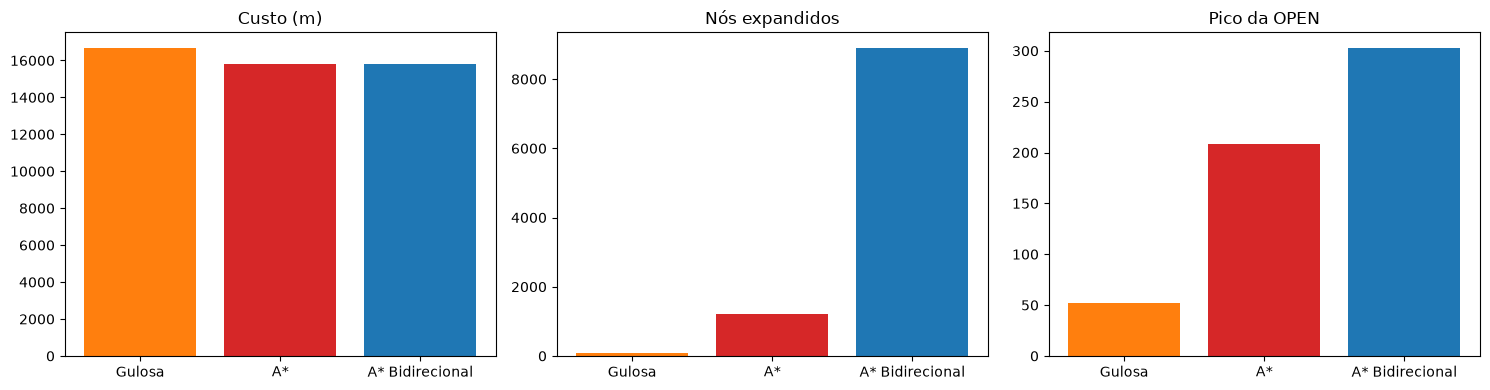

In [7]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, coluna in zip(eixos, ['Custo (m)', 'Nós expandidos', 'Pico da OPEN']):
  eixo.bar(df_busca['Algoritmo'], df_busca[coluna], color=['tab:orange', 'tab:red', 'tab:blue'])
  eixo.set_title(coluna)
plt.tight_layout()
plt.show()

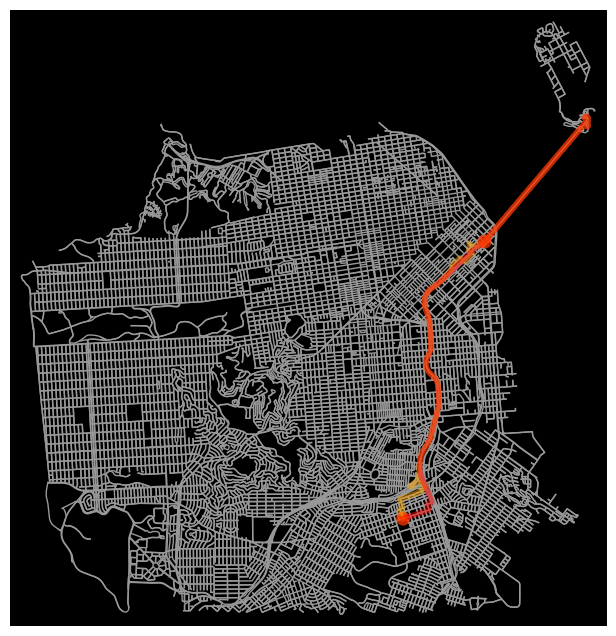

In [8]:
#Rotas no mapa: Gulosa (laranja) x A* (vermelho). O bidirecional encontra a mesma rota do A*.
fig, ax = ox.plot_graph_routes(
    G_conexo,
    [resultados[0]['caminho'], resultados[1]['caminho']],
    route_colors=['orange', 'red'],
    route_linewidths=4,
    node_size=0,
    bgcolor='k',
)

### Outros trajetos
Para não depender de um único par, repetimos a comparação em quatro trajetos entre pontos conhecidos da cidade. Cada ponto é ligado ao cruzamento mais próximo do mapa.

In [9]:
locais = {
    "Fisherman's Wharf": (37.8080, -122.4177),
    'Mission Dolores': (37.7599, -122.4268),
    'Ocean Beach': (37.7600, -122.5090),
    'Ferry Building': (37.7955, -122.3937),
    'Presidio': (37.7989, -122.4662),
    'Bayview': (37.7300, -122.3900),
    'Twin Peaks': (37.7544, -122.4477),
}
trajetos = [("Fisherman's Wharf", 'Mission Dolores'), ('Ocean Beach', 'Ferry Building'),
            ('Presidio', 'Bayview'), ('Twin Peaks', "Fisherman's Wharf")]

def no_mais_proximo(nome):
  lat, lon = locais[nome]
  return ox.distance.nearest_nodes(G_conexo, lon, lat)

linhas, rotas = [], []
for a, b in trajetos:
  o, d = no_mais_proximo(a), no_mais_proximo(b)
  otimo = nx.shortest_path_length(G_conexo, o, d, weight='length')
  res = [busca(G_conexo, o, d, 'Gulosa'), busca(G_conexo, o, d, 'A*'), a_estrela_bidirecional(G_conexo, o, d)]
  rotas.append((f'{a} → {b}', res[0]['caminho'], res[1]['caminho']))
  for r in res:
    linhas.append({
        'Trajeto': f'{a} → {b}',
        'Algoritmo': r['Algoritmo'],
        'Custo (m)': r['Custo (m)'],
        'Acima do ótimo': f"{round((r['Custo (m)'] / otimo - 1) * 100, 1) + 0.0:+.1f}%",
        'Nós expandidos': r['Nós expandidos'],
        'Pico da OPEN': r['Pico da OPEN'],
    })
pd.DataFrame(linhas).set_index(['Trajeto', 'Algoritmo'])

Custo (m) Acima do ótimo  \
Trajeto                             Algoritmo                                   
Fisherman's Wharf → Mission Dolores Gulosa             6719.71         +10.0%   
                                    A*                 6107.39          +0.0%   
                                    A* Bidirecional    6107.39          +0.0%   
Ocean Beach → Ferry Building        Gulosa            14191.62         +13.4%   
                                    A*                12511.86          +0.0%   
                                    A* Bidirecional   12511.86          +0.0%   
Presidio → Bayview                  Gulosa            17476.65         +28.2%   
                                    A*                13629.60          +0.0%   
                                    A* Bidirecional   13629.60          +0.0%   
Twin Peaks → Fisherman's Wharf      Gulosa            12205.72         +12.3%   
                                    A*                10870.46          +0.0%   
                                    A* Bidirecional   10870.46          +0.0%   

                                                     Nós expandidos  \
Trajeto                             Algoritmo                         
Fisherman's Wharf → Mission Dolores Gulosa                       84   
                                    A*                          695   
                                    A* Bidirecional            1625   
Ocean Beach → Ferry Building        Gulosa                      121   
                                    A*                         2466   
                                    A* Bidirecional            5866   
Presidio → Bayview                  Gulosa                      183   
                                    A*                         4153   
                                    A* Bidirecional           10027   
Twin Peaks → Fisherman's Wharf      Gulosa                      102   
                                    A*                         1965   
                                    A* Bidirecional            6365   

                                                     Pico da OPEN  
Trajeto                             Algoritmo                      
Fisherman's Wharf → Mission Dolores Gulosa                     90  
                                    A*                        169  
                                    A* Bidirecional           328  
Ocean Beach → Ferry Building        Gulosa                    130  
                                    A*                        283  
                                    A* Bidirecional           583  
Presidio → Bayview                  Gulosa                    207  
                                    A*                        269  
                                    A* Bidirecional           483  
Twin Peaks → Fisherman's Wharf      Gulosa                    113  
                                    A*                        240  
                                    A* Bidirecional           362

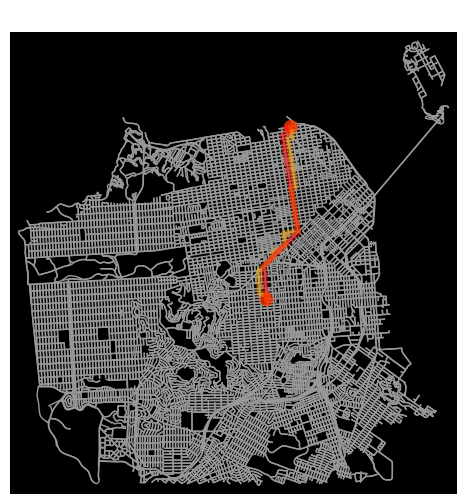

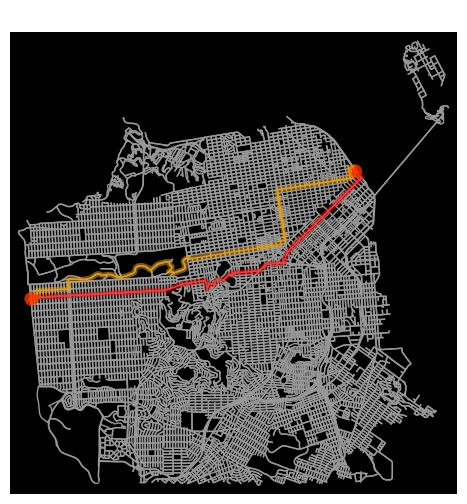

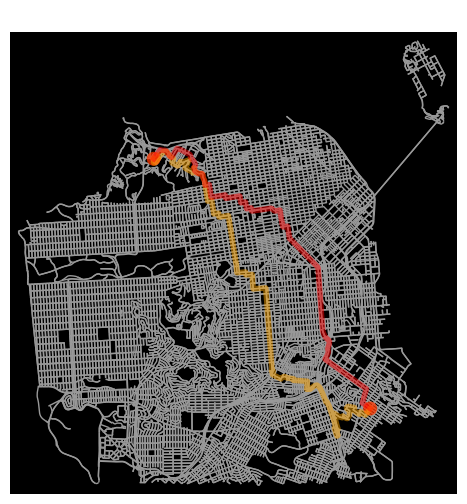

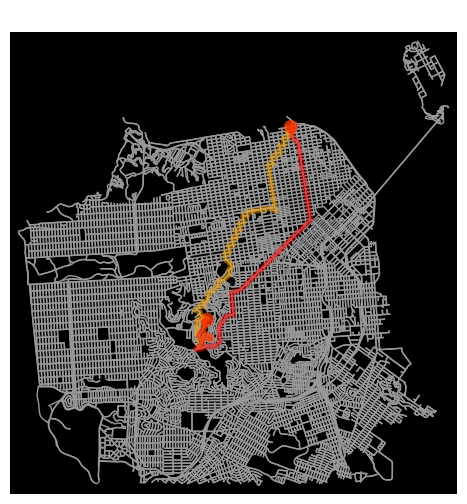

In [10]:
#Gulosa (laranja) x A* (vermelho) em cada trajeto
for nome, rota_gulosa, rota_astar in rotas:
  fig, ax = ox.plot_graph_routes(G_conexo, [rota_gulosa, rota_astar], route_colors=['orange', 'red'],
                                 route_linewidths=4, node_size=0, bgcolor='k', figsize=(6, 6),
                                 show=False, close=False)
  ax.set_title(nome, color='white', fontsize=13)
  fig.set_facecolor('k')
  plt.show()

### Análise dos resultados (Parte I)

**Verificação:** em todos os trajetos, o A\* e o A\* Bidirecional encontraram o mesmo custo do Dijkstra. As duas soluções são sempre ótimas.

1. **Busca Gulosa:** foi sempre a mais rápida (menos de 200 nós expandidos), mas nunca achou a rota ótima: ficou de 5,5% a 28% mais longa. Como olha só para $h(n)$, segue o que *parece* mais perto do destino e ignora quanto já andou.
2. **A\*:** achou a rota ótima em todos os trajetos, expandindo de 695 a 4.153 nós, conforme a distância. A heurística evita explorar a cidade inteira.
3. **A\* Bidirecional:** também foi sempre ótimo, mas expandiu **de 2,3 a 7 vezes mais nós** que o A\*. A causa principal é o critério de parada de Pohl: ele só para quando uma das frentes não tem mais nenhum nó com $f$ menor que o melhor custo, e isso obriga cada frente a explorar quase tudo o que um A\* completo exploraria. No primeiro par a diferença é maior (7 vezes) porque a origem fica **em cima da Bay Bridge**: a única saída é atravessar a ponte até a ilha de Yerba Buena e voltar, então a rota real (15,8 km) tem mais que o dobro da linha reta (6,7 km) e a heurística guia mal as duas frentes.

**Limitações e melhorias:** o tempo em segundos depende da máquina, por isso nós expandidos e pico da OPEN são as medidas mais confiáveis. Para o bidirecional ganhar do A\*, seriam necessários critérios de parada mais fortes ou heurísticas balanceadas entre as frentes, que ficam fora do escopo deste trabalho.

# Parte II: Árvore de decisão — classificar a qualidade de vinhos

### Problema
Prever se um vinho tinto é **bom** usando apenas medidas de laboratório (teor alcoólico, acidez, sulfatos etc.), sem depender de um provador.

### Dados
Base **Wine Quality (vinho tinto)**, do OpenML: 1.599 vinhos portugueses, 11 medidas físico-químicas e uma nota de 0 a 10 dada por especialistas. Transformamos a nota em duas classes: **Bom** (nota ≥ 6) e **Comum** (nota < 6). Separamos 80% dos vinhos para treino e 20% para teste (vinhos que o modelo nunca viu).

### Por que árvores de decisão
Os dados são uma tabela de números, e a árvore gera regras do tipo "se o álcool for maior que X, então..." que podem ser lidas, explicadas e conferidas com o que se sabe sobre vinhos.

### Algoritmos
* **Árvore de decisão (C4.5):** a cada passo, escolhe a pergunta que mais separa vinhos bons de comuns. O C4.5 mede isso pela **entropia** (o quanto as classes estão misturadas) e escolhe a pergunta que mais reduz essa mistura. Usamos o `DecisionTreeClassifier` do scikit-learn com `criterion='entropy'`, que segue esse mesmo princípio. Diferença: o C4.5 original usa a *razão de ganho* e poda a árvore depois de pronta; aqui o tamanho é controlado pela profundidade máxima.
* **Random Forest (ensemble):** treina 100 árvores, cada uma com uma amostra sorteada dos vinhos e dos atributos, e decide pela **votação** entre elas. Costuma acertar mais, mas não dá para ler 100 árvores como um conjunto de regras.

### Meta e critérios (definidos antes dos experimentos)
* **Meta: acertar pelo menos 70% dos vinhos de teste com a menor árvore possível.** Para comparação, chutar "Bom" para todos os vinhos acerta 53,5%.
* Critérios: taxa de acertos, profundidade, número de folhas (regras finais), clareza das regras e estabilidade quando os dados de treino mudam.

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

df_vinho = fetch_openml(name='wine-quality-red', version=1, as_frame=True).frame
df_vinho['nota'] = df_vinho.pop('class').astype(int)

X = df_vinho.drop(columns='nota')
y = (df_vinho['nota'] >= 6).astype(int)  #1 = Bom, 0 = Comum

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'{len(X)} vinhos: {len(X_treino)} para treino e {len(X_teste)} para teste')
print(f'Proporção de vinhos bons: {y.mean():.1%}')

1599 vinhos: 1279 para treino e 320 para teste
Proporção de vinhos bons: 53.5%


In [12]:
#Busca da árvore mais enxuta que atinge a meta
META = 0.70
linhas = []
for profundidade in range(1, 9):
  arvore = DecisionTreeClassifier(criterion='entropy', max_depth=profundidade, random_state=42)
  arvore.fit(X_treino, y_treino)
  linhas.append({
      'Profundidade': profundidade,
      'Folhas': arvore.get_n_leaves(),
      'Acurácia no teste': round(accuracy_score(y_teste, arvore.predict(X_teste)), 3),
  })
df_tamanhos = pd.DataFrame(linhas)

prof_escolhida = df_tamanhos.loc[df_tamanhos['Acurácia no teste'] >= META, 'Profundidade'].min()
print(f'Menor profundidade que atinge a meta de {META:.0%}: {prof_escolhida}')
df_tamanhos

Menor profundidade que atinge a meta de 70%: 4


,Profundidade,Folhas,Acurácia no teste
0,1,2,0.691
1,2,4,0.691
2,3,8,0.684
3,4,16,0.709
4,5,28,0.700
5,6,44,0.728
6,7,64,0.738
7,8,86,0.719


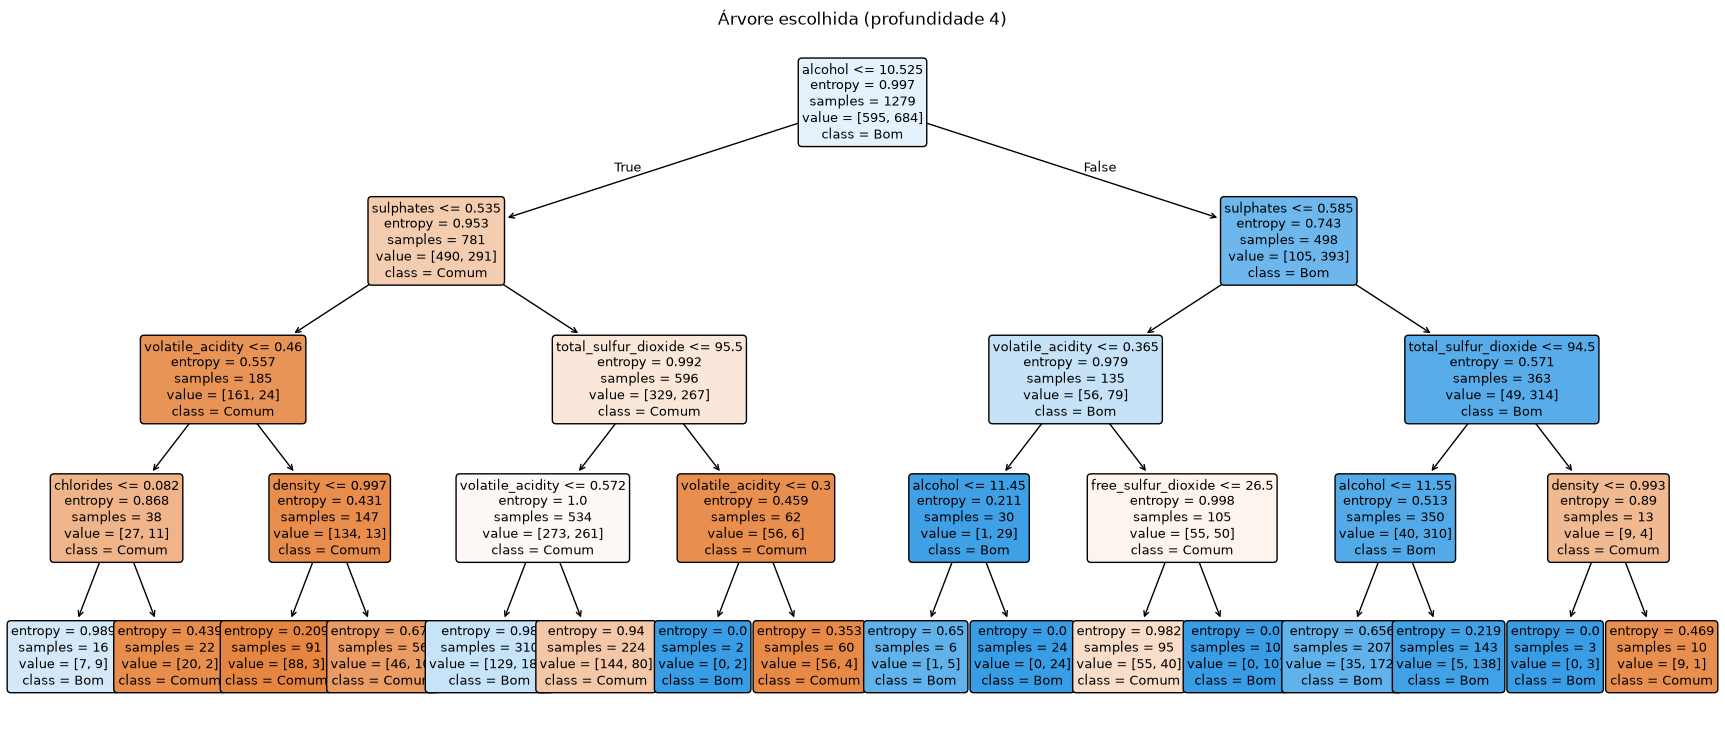

|--- alcohol <= 10.53
|   |--- sulphates <= 0.53
|   |   |--- volatile_acidity <= 0.46
|   |   |   |--- chlorides <= 0.08
|   |   |   |   |--- class: 1
|   |   |   |--- chlorides >  0.08
|   |   |   |   |--- class: 0
|   |   |--- volatile_acidity >  0.46
|   |   |   |--- density <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- density >  1.00
|   |   |   |   |--- class: 0
|   |--- sulphates >  0.53
|   |   |--- total_sulfur_dioxide <= 95.50
|   |   |   |--- volatile_acidity <= 0.57
|   |   |   |   |--- class: 1
|   |   |   |--- volatile_acidity >  0.57
|   |   |   |   |--- class: 0
|   |   |--- total_sulfur_dioxide >  95.50
|   |   |   |--- volatile_acidity <= 0.30
|   |   |   |   |--- class: 1
|   |   |   |--- volatile_acidity >  0.30
|   |   |   |   |--- class: 0
|--- alcohol >  10.53
|   |--- sulphates <= 0.58
|   |   |--- volatile_acidity <= 0.37
|   |   |   |--- alcohol <= 11.45
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  11.45
|   |   |   |   |--- class: 1
|  

In [13]:
arvore = DecisionTreeClassifier(criterion='entropy', max_depth=prof_escolhida, random_state=42)
arvore.fit(X_treino, y_treino)

plt.figure(figsize=(22, 9))
plot_tree(arvore, feature_names=X.columns, class_names=['Comum', 'Bom'],
          filled=True, rounded=True, fontsize=9)
plt.title(f'Árvore escolhida (profundidade {prof_escolhida})')
plt.show()

#As mesmas regras em texto
print(export_text(arvore, feature_names=list(X.columns)))

In [14]:
floresta = RandomForestClassifier(n_estimators=100, random_state=42)
floresta.fit(X_treino, y_treino)

pd.DataFrame([
    {'Modelo': 'Árvore de decisão',
     'Acurácia no teste': round(accuracy_score(y_teste, arvore.predict(X_teste)), 3),
     'Árvores': 1,
     'Profundidade': arvore.get_depth(),
     'Folhas': arvore.get_n_leaves()},
    {'Modelo': 'Random Forest',
     'Acurácia no teste': round(accuracy_score(y_teste, floresta.predict(X_teste)), 3),
     'Árvores': len(floresta.estimators_),
     'Profundidade': round(sum(a.get_depth() for a in floresta.estimators_) / 100, 1),
     'Folhas': round(sum(a.get_n_leaves() for a in floresta.estimators_) / 100, 1)},
]).set_index('Modelo')

,Acurácia no teste,Árvores,Profundidade,Folhas
Modelo,,,,
Árvore de decisão,0.709,1,4.0,16.0
Random Forest,0.806,100,17.3,190.2


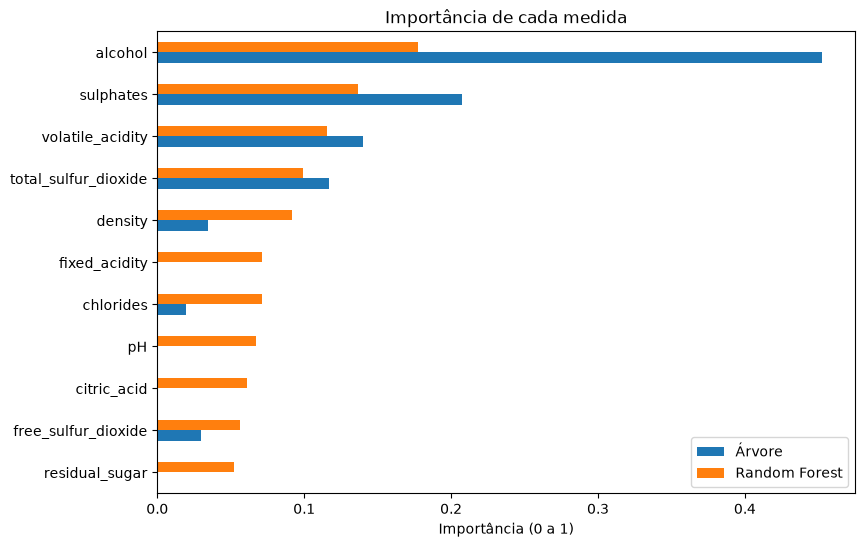

In [15]:
#Decisões mais importantes: quanto cada medida ajudou a separar as classes
importancias = pd.DataFrame({
    'Árvore': arvore.feature_importances_,
    'Random Forest': floresta.feature_importances_,
}, index=X.columns).sort_values('Random Forest')

importancias.plot.barh(figsize=(9, 6))
plt.title('Importância de cada medida')
plt.xlabel('Importância (0 a 1)')
plt.show()

In [16]:
#Exemplos de acertos e erros da árvore, comparados com a nota real
exemplos = X_teste[['alcohol', 'sulphates', 'volatile_acidity']].copy()
exemplos['Nota real'] = df_vinho.loc[X_teste.index, 'nota']
exemplos['Classe real'] = y_teste.map({1: 'Bom', 0: 'Comum'})
exemplos['Árvore'] = pd.Series(arvore.predict(X_teste), index=X_teste.index).map({1: 'Bom', 0: 'Comum'})
exemplos['Random Forest'] = pd.Series(floresta.predict(X_teste), index=X_teste.index).map({1: 'Bom', 0: 'Comum'})

acertos = exemplos[exemplos['Árvore'] == exemplos['Classe real']].head(3)
erros = exemplos[exemplos['Árvore'] != exemplos['Classe real']].head(3)
pd.concat([acertos, erros])

,alcohol,sulphates,volatile_acidity,Nota real,Classe real,Árvore,Random Forest
1391,11.0,0.58,0.640,5,Comum,Comum,Bom
170,9.1,0.33,0.885,4,Comum,Comum,Comum
461,9.3,0.61,0.615,5,Comum,Comum,Comum
100,10.2,0.61,0.610,6,Bom,Comum,Comum
776,10.3,0.60,0.765,6,Bom,Comum,Comum
91,9.9,1.95,0.490,6,Bom,Comum,Bom


In [17]:
#Estabilidade: repetir com 5 divisões diferentes entre treino e teste
linhas = []
for semente in [0, 1, 2, 3, 42]:
  Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=semente, stratify=y)
  a = DecisionTreeClassifier(criterion='entropy', max_depth=prof_escolhida, random_state=42).fit(Xa, ya)
  f = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xa, ya)
  linhas.append({
      'Divisão': semente,
      'Acurácia árvore': round(accuracy_score(yb, a.predict(Xb)), 3),
      'Acurácia Random Forest': round(accuracy_score(yb, f.predict(Xb)), 3),
      'Primeira pergunta da árvore': f'{X.columns[a.tree_.feature[0]]} <= {a.tree_.threshold[0]:.2f}',
  })
df_estab = pd.DataFrame(linhas).set_index('Divisão')
display(df_estab)
print(df_estab[['Acurácia árvore', 'Acurácia Random Forest']].agg(['mean', 'min', 'max']).round(3))

,Acurácia árvore,Acurácia Random Forest,Primeira pergunta da árvore
Divisão,,,
0,0.741,0.834,alcohol <= 10.53
1,0.725,0.791,alcohol <= 10.25
2,0.731,0.828,alcohol <= 10.53
3,0.741,0.778,alcohol <= 9.97
42,0.709,0.806,alcohol <= 10.53


      Acurácia árvore  Acurácia Random Forest
mean            0.729                   0.807
min             0.709                   0.778
max             0.741                   0.834


### Análise dos resultados (Parte II)

**Verificação:** o A\* e o A\* Bidirecional encontraram a rota de **15.819,74 m**, o mesmo custo dado pelo Dijkstra. As duas soluções são ótimas.

1. **Busca Gulosa:** foi a mais rápida (90 nós expandidos), mas a rota ficou **5,5% mais longa** (16.688 m). Como olha só para $h(n)$, ela segue o que *parece* mais perto do destino e ignora quanto já andou.
2. **A\*:** encontrou a rota ótima expandindo 1.221 nós, cerca de 12% do mapa. A heurística evitou explorar o resto da cidade.
3. **A\* Bidirecional:** também achou a rota ótima, mas expandiu **mais nós** (8.907) e usou mais memória (303) que o A\*. O motivo aparece no mapa: a origem fica **em cima da Bay Bridge**, e a única saída é atravessar a ponte até a ilha de Yerba Buena, fazer o retorno e voltar. Por isso a rota real (15,8 km) tem mais que o dobro da linha reta (6,7 km). A heurística guia mal a busca nesse caso, e as duas frentes não se encontram no meio. Com o critério de parada de Pohl, cada frente acaba fazendo quase um A\* completo. O ganho da variante depende de uma heurística que se aproxime bem do custo real.

**Limitações e melhorias:** foi testado um único par origem–destino, escolhido pela posição na lista de nós e não pela localização (por isso caiu na ponte); testar vários pares daria uma comparação mais geral. O tempo em segundos depende da máquina, por isso nós expandidos e pico da OPEN são as medidas mais confiáveis. Para o bidirecional, existem critérios de parada e heurísticas balanceadas que reduzem os nós expandidos.I

# Referências
* RUSSELL, S.; NORVIG, P. *Inteligência Artificial: uma abordagem moderna*. 4. ed. Rio de Janeiro: GEN LTC, 2022.
* HART, P. E.; NILSSON, N. J.; RAPHAEL, B. A Formal Basis for the Heuristic Determination of Minimum Cost Paths. *IEEE Transactions on Systems Science and Cybernetics*, v. 4, n. 2, p. 100–107, 1968.
* POHL, I. Bi-directional Search. *Machine Intelligence*, v. 6, p. 127–140, 1971.
* BOEING, G. OSMnx: New Methods for Acquiring, Constructing, Analyzing, and Visualizing Complex Street Networks. *Computers, Environment and Urban Systems*, v. 65, p. 126–139, 2017.
* QUINLAN, J. R. *C4.5: Programs for Machine Learning*. San Mateo: Morgan Kaufmann, 1993.
* BREIMAN, L. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.
* CORTEZ, P. et al. Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, v. 47, n. 4, p. 547–553, 2009.
* Documentação do scikit-learn: https://scikit-learn.org/stable/modules/tree.html